# Example Testing

## Package

### Graph Visualization

[NetworkX](https://networkx.org/documentation/stable/tutorial.html)

In [134]:
%pip install networkx
%pip install matplotlib

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


Declaring

In [135]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

Testing

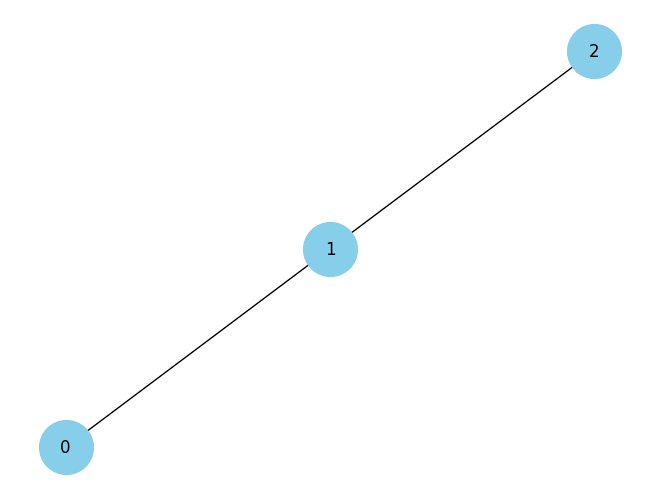

In [136]:
adj_matrix = np.array([
    [0, 1, 0],
    [1, 0, 1],
    [0, 1, 0]
])
G = nx.from_numpy_array(adj_matrix)
nx.draw(G, with_labels=True, node_color='skyblue', node_size=1500)
plt.show()

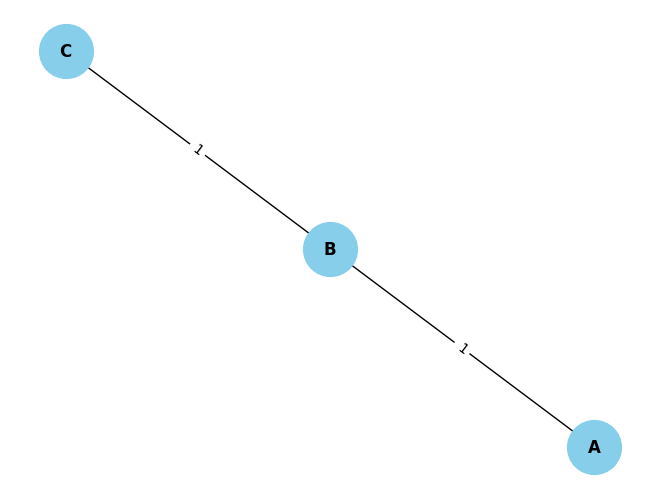

In [137]:
G = nx.from_numpy_array(adj_matrix)

mapping = {i: chr(65 + i) for i in G.nodes}
G = nx.relabel_nodes(G, mapping)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size=1500, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)

plt.show()

### Expression

In [138]:
%pip install sympy

Note: you may need to restart the kernel to use updated packages.


Declaring

In [139]:
from sympy import symbols, Eq, solve

Testing

$x-4 = (1-x) + 5$

In [140]:
x = symbols('x')
equation = Eq(x - 4, (1-x) + 5)
solution = solve(equation, x)
print(solution)

[5]


### Shortest-path

[Source code](https://www.geeksforgeeks.org/python-program-for-dijkstras-shortest-path-algorithm-greedy-algo-7/)

Declaring

In [141]:
import sys
sys.path.append('ipynb/location/packages')
from packages import ShortestPath

Graph parameter

In [142]:
g = ShortestPath.Graph(9)
g.graph = [[0, 4, 0, 0, 0, 0, 0, 8, 0],
           [4, 0, 8, 0, 0, 0, 0, 11, 0],
           [0, 8, 0, 7, 0, 4, 0, 0, 2],
           [0, 0, 7, 0, 9, 14, 0, 0, 0],
           [0, 0, 0, 9, 0, 10, 0, 0, 0],
           [0, 0, 4, 14, 10, 0, 2, 0, 0],
           [0, 0, 0, 0, 0, 2, 0, 1, 6],
           [8, 11, 0, 0, 0, 0, 1, 0, 7],
           [0, 0, 2, 0, 0, 0, 6, 7, 0]
           ]

Visualization

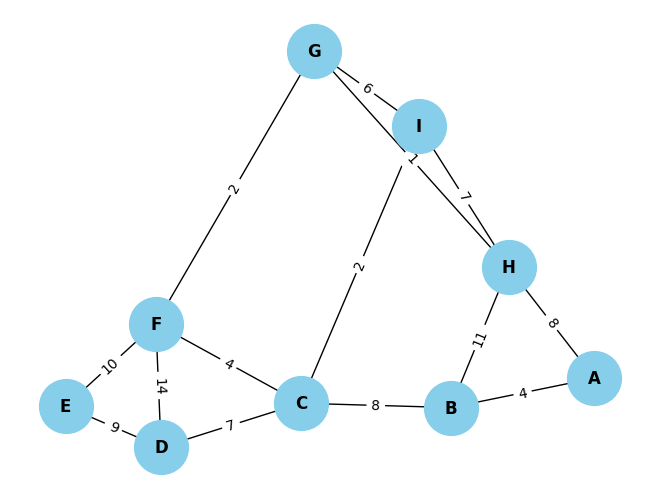

In [143]:
graphVisual = np.array(g.graph)
G = nx.from_numpy_array(graphVisual)
mapping = {i: chr(65 + i) for i in G.nodes}
G = nx.relabel_nodes(G, mapping)

pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_color='skyblue', node_size =1500, font_weight='bold')
edge_labels = nx.get_edge_attributes(G, 'weight')
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels)
plt.show()

Input 2 point requested

In [144]:
start = 'D'
end = 'A'

Execute

In [145]:
startInput = ord(start) - 65
endInput = ord(end) - 65
path, distance = g.getShortestPath(startInput, endInput)
result = [chr(65 + i) for i in path]
print(result)
print("Total distance:", distance)

['D', 'C', 'B', 'A']
Total distance: 19


## Bottleneck point

For $v \in V, \: x = (e, \alpha) \in G$, the bottleneck point $v$ on $e=(v_i,v_j)$ is

$$
\alpha l_e + d(v_i, v) = (1-\alpha ) l_e + d(v_j, v)
$$

- $BP_e$: Set of all bottleneck points on $e \in E$.

- $BP$: Set of all bottleneck points on $G$.

In [146]:
from packages import Bottleneck

In [147]:
testGraphBN = [[0, 4, 0, 0, 0, 0, 0, 8, 0],
                [4, 0, 8, 0, 0, 0, 0, 11, 0],
                [0, 8, 0, 7, 0, 4, 0, 0, 2],
                [0, 0, 7, 0, 9, 14, 0, 0, 0],
                [0, 0, 0, 9, 0, 10, 0, 0, 0],
                [0, 0, 4, 14, 10, 0, 2, 0, 0],
                [0, 0, 0, 0, 0, 2, 0, 1, 6],
                [8, 11, 0, 0, 0, 0, 1, 0, 7],
                [0, 0, 2, 0, 0, 0, 6, 7, 0]
                ]

In [148]:
a = Bottleneck.BottleNeck(testGraphBN, 9, 'A', 'B', 'C')
print(a.alpha())

[0]


In [149]:
a = Bottleneck.BottleNeck(testGraphBN, 9, 'A', 'B', 'H')
print(a.alpha())

[7/8]


## Equilibrium point

For $v_k, v_l \in V, \: v_k \neq v_l, \: x = (e, \alpha) \in G, \: e= (v_u, v_v)$, the equililbrium point is

$$
\omega _k (\alpha l_e+ d(v_k, v_u)) = \omega _l ((1-\alpha )l_e + d(v_l, v_v))
$$

If $x \in G$

$$
\omega _k d(v_k, x) = \omega _l d(v_l, x)
$$

- $EQ_e$: Set of all equilibrium points on $e \in E$.

- $EQ$: Set of all equilibrium points on $G$.

## Local center

For $e \in E, \: e = (v_i, v_j)$, the local center on $e$ is

$$
\arg \underset{x \in e}{\min} f(x) = \arg \min \{ \underset{x \in EQ_e}{\min} f(x), f(v_i), f(v_j) \}
$$

## Global center